In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_raw = pd.read_csv('output/salary_data_cleaned.csv')

In [3]:
df = df_raw.copy(deep = 1)
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,avg_salary,company_txt,job_state,same_state,age,python_yn,R_yn,spark,aws,excel
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\r\nLocation: Albuquerque, NM\r\...",3.8,Tecolote Research\r\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,...,72.0,Tecolote Research\r\n,NM,0,53,1,0,0,0,1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\r\n\r\nI. General Summary\r\...,3.4,University of Maryland Medical System\r\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,...,87.5,University of Maryland Medical System\r\n,MD,0,42,1,0,0,0,0
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\r\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,...,85.0,KnowBe4\r\n,FL,1,16,1,0,1,0,1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\r\nJob ID: 310709\r...,3.8,PNNL\r\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,...,76.5,PNNL\r\n,WA,1,61,1,0,0,0,0
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\r\nAffinity Solutions / Marketi...,2.9,Affinity Solutions\r\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,...,114.5,Affinity Solutions\r\n,NY,1,28,1,0,0,0,1


In [4]:
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'R_yn',
       'spark', 'aws', 'excel'],
      dtype='str')

In [5]:
def title_simplifier(title):

    if 'data scientist' in title.lower():
        return 'data scientist'
    
    elif 'data engineer' in title.lower():
        return 'data engineer'
    
    elif 'analyst' in title.lower():
        return 'analyst'
    
    elif 'manager' in title.lower():
        return 'manager'
    
    elif 'director' in title.lower():
        return 'director'
    
    else: return 'na'


def seniority(title):
    if 'sr' in title.lower() or 'senior' in title.lower() or 'lead' in title.lower() or 'principal' in title.lower():
        return 'senior'
    
    elif 'jr' in title.lower():
        return 'jr'
    
    else: return 'na'


In [6]:
df['job_simp'] = df['Job Title'].apply(title_simplifier)

df['job_simp']

0      data scientist
1      data scientist
2      data scientist
3      data scientist
4      data scientist
            ...      
737                na
738     data engineer
739                na
740           manager
741                na
Name: job_simp, Length: 742, dtype: str

In [7]:
df['seniority'] = df['Job Title'].apply(seniority)

df['seniority']

0          na
1          na
2          na
3          na
4          na
        ...  
737    senior
738    senior
739        na
740        na
741        na
Name: seniority, Length: 742, dtype: str

In [8]:
df['job_state'] = df.job_state.apply(lambda x : x.strip() if x.strip().lower() != 'los angles' else 'CA')
df.job_state.value_counts()

job_state
CA             151
MA             103
NY              72
VA              41
IL              40
MD              35
PA              33
TX              28
WA              21
NC              21
NJ              17
FL              16
OH              14
TN              13
CO              11
DC              11
IN              10
WI              10
UT              10
MO               9
AZ               9
AL               8
KY               6
MI               6
GA               6
DE               6
CT               5
IA               5
OR               4
LA               4
NE               4
NM               3
KS               3
MN               2
ID               2
Los Angeles      1
RI               1
SC               1
Name: count, dtype: int64

In [9]:
df['desc_len'] = df['Job Description'].apply(lambda x : len(x))
df['desc_len']

0      2555
1      4828
2      3495
3      3926
4      2748
       ... 
737    6219
738    6167
739    3107
740    1678
741    3710
Name: desc_len, Length: 742, dtype: int64

In [10]:
df['num_comp'] = df['Competitors'].apply(lambda x : len(x.split(',')) if x != '-1' else 0)

In [11]:
df['Competitors']

0                                                     -1
1                                                     -1
2                                                     -1
3      Oak Ridge National Laboratory, National Renewa...
4                   Commerce Signals, Cardlytics, Yodlee
                             ...                        
737                           Pfizer, AstraZeneca, Merck
738                      See Tickets, TicketWeb, Vendini
739                                                   -1
740                                                   -1
741                                                   -1
Name: Competitors, Length: 742, dtype: str

In [12]:
# hourly wage to annual
df['min_salary'] = df.apply(lambda x : x.min_salary*2 if x.hourly == 1 else x.min_salary, axis = 1)

In [13]:
df['min_salary']

0      53
1      63
2      80
3      56
4      86
       ..
737    58
738    72
739    56
740    95
741    61
Name: min_salary, Length: 742, dtype: int64

In [14]:
df['max_salary'] = df.apply(lambda x : x.max_salary*2 if x.hourly == 1 else x.max_salary, axis = 1)
df['max_salary']

0       91
1      112
2       90
3       97
4      143
      ... 
737    111
738    133
739     91
740    160
741    126
Name: max_salary, Length: 742, dtype: int64

In [15]:
df.company_txt

0                          Tecolote Research\r\n
1      University of Maryland Medical System\r\n
2                                    KnowBe4\r\n
3                                       PNNL\r\n
4                         Affinity Solutions\r\n
                         ...                    
737                                      GSK\r\n
738                               Eventbrite\r\n
739           Software Engineering Institute\r\n
740                             Numeric, LLC\r\n
741             Riverside Research Institute\r\n
Name: company_txt, Length: 742, dtype: str

In [16]:
df['company_txt'] = df.company_txt.apply(lambda x : x.replace('\n', ''))

In [17]:
df.describe()

,Unnamed: 0,Rating,Founded,hourly,employer_provided,min_salary,max_salary,avg_salary,same_state,age,python_yn,R_yn,spark,aws,excel,desc_len,num_comp
count,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,469.129380,3.618868,1837.154987,0.032345,0.022911,74.719677,128.149596,100.626011,0.557951,52.187332,0.528302,0.002695,0.225067,0.237197,0.522911,3910.172507,1.053908
std,279.793117,0.801210,497.183763,0.177034,0.149721,30.980593,45.220324,38.855948,0.496965,54.156829,0.499535,0.051882,0.417908,0.425651,0.499812,1533.827777,1.384239
min,0.000000,-1.000000,-1.000000,0.000000,0.000000,15.000000,16.000000,13.500000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000
25%,221.500000,3.300000,1939.000000,0.000000,0.000000,52.000000,96.000000,73.500000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2834.000000,0.000000
50%,472.500000,3.700000,1988.000000,0.000000,0.000000,69.500000,124.000000,97.500000,1.000000,30.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3781.500000,0.000000
75%,707.750000,4.000000,2007.000000,0.000000,0.000000,91.000000,155.000000,122.500000,1.000000,65.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4772.000000,3.000000
max,955.000000,5.000000,2019.000000,1.000000,1.000000,202.000000,306.000000,254.000000,1.000000,282.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10146.000000,4.000000


<Axes: >

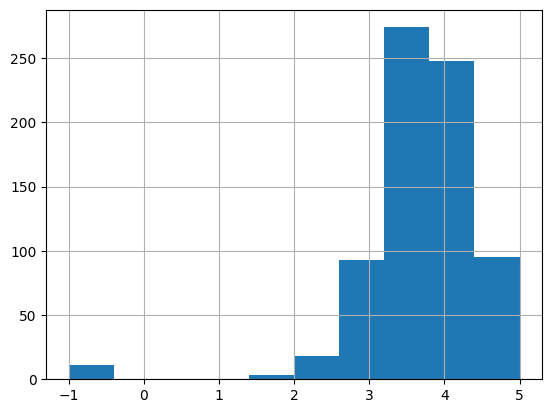

In [18]:
df.Rating.hist()

<Axes: >

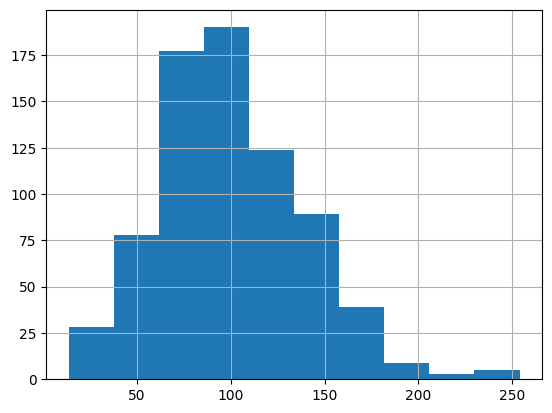

In [19]:
df.avg_salary.hist()

<Axes: >

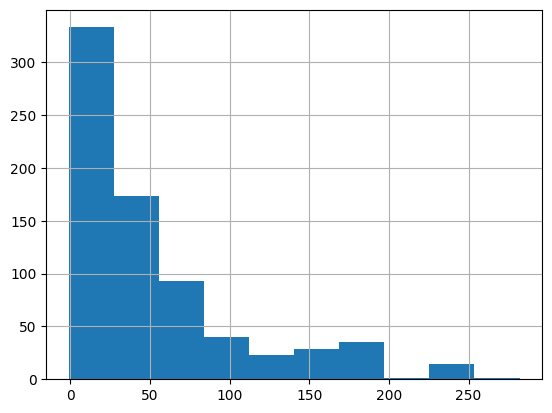

In [20]:
df.age.hist()

<Axes: >

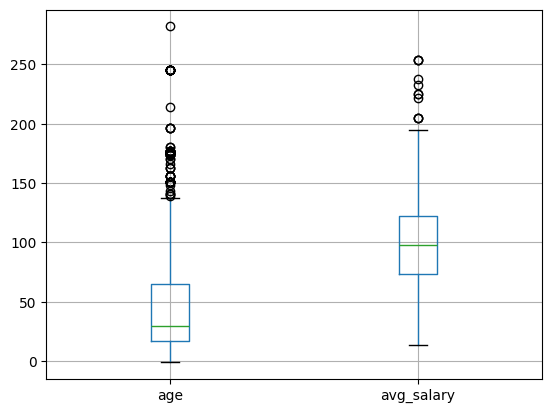

In [22]:
df.boxplot(column= ['age', 'avg_salary'])

<Axes: >

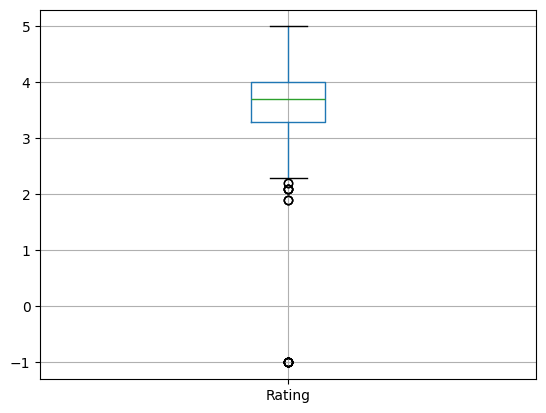

In [23]:
df.boxplot(column=['Rating'])

In [25]:
df[['age', 'avg_salary', 'Rating', 'desc_len']].corr()

,age,avg_salary,Rating,desc_len
age,1.000000,0.019163,0.030637,0.166656
avg_salary,0.019163,1.000000,0.013492,0.078093
Rating,0.030637,0.013492,1.000000,-0.012631
desc_len,0.166656,0.078093,-0.012631,1.000000


<Axes: >

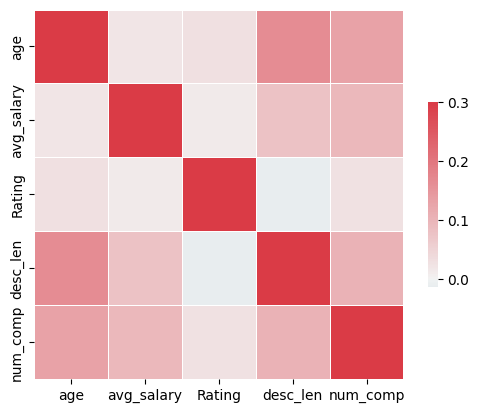

In [28]:
cmap = sns.diverging_palette(220, 10, as_cmap= True)

sns.heatmap(df[['age', 'avg_salary', 'Rating', 'desc_len', 'num_comp']].corr(), vmax= .3, center = 0, square= True, cmap= cmap, linewidth= .5, cbar_kws= {'shrink':.5})

In [29]:
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'R_yn',
       'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_len',
       'num_comp'],
      dtype='str')

In [32]:
df = df.drop('Unnamed: 0', axis=1)

In [33]:
df_cat = df[['Location', 'Headquarters', 'Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'R_yn',
       'spark', 'aws', 'excel', 'job_simp', 'seniority']]

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


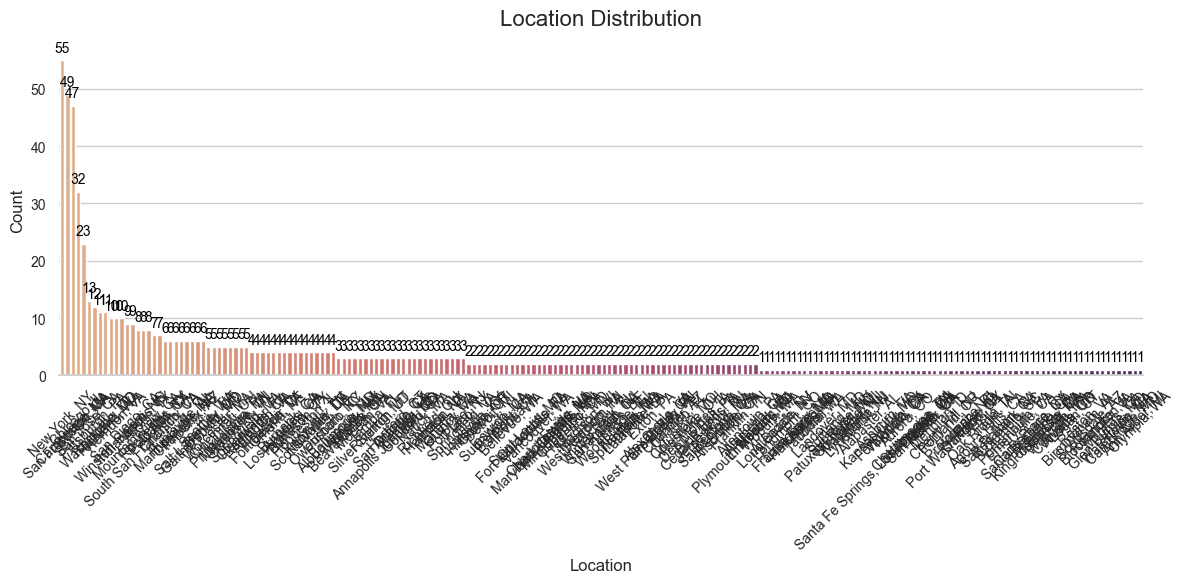

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


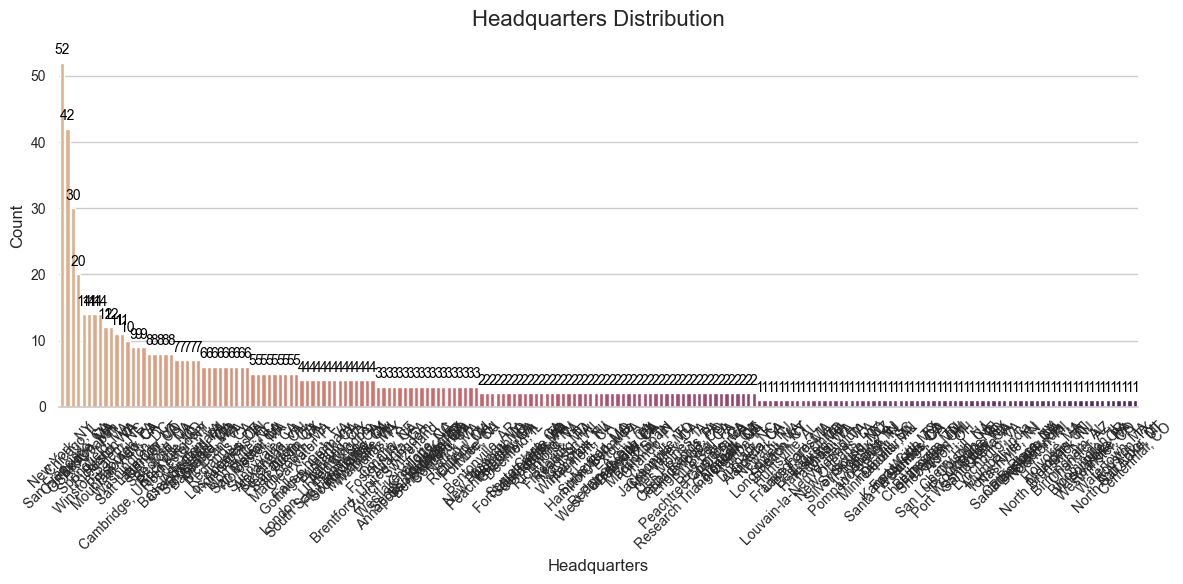

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


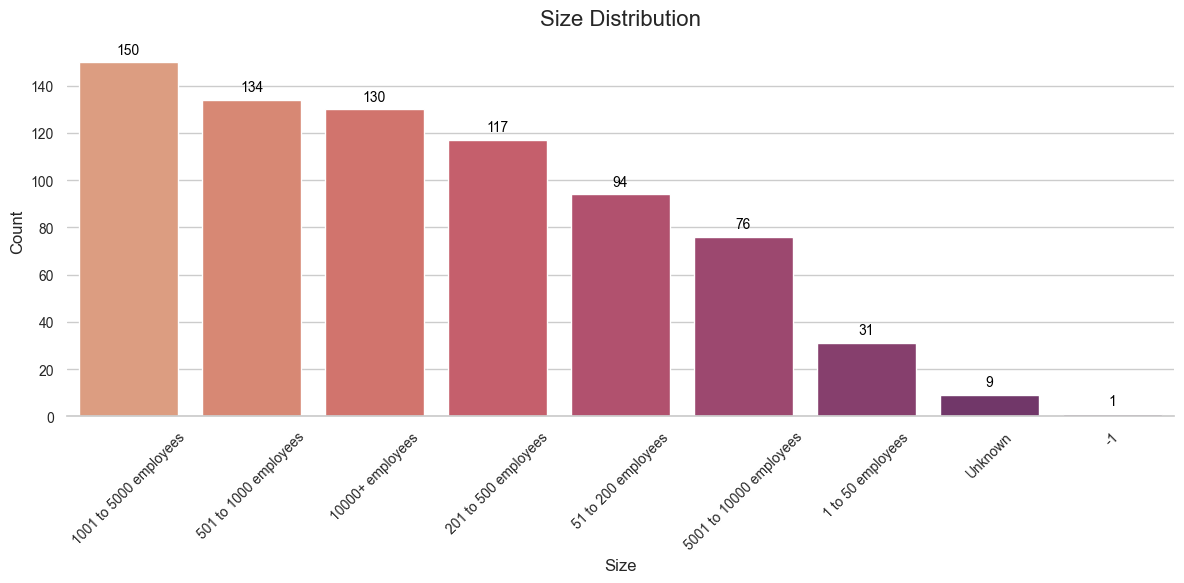

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


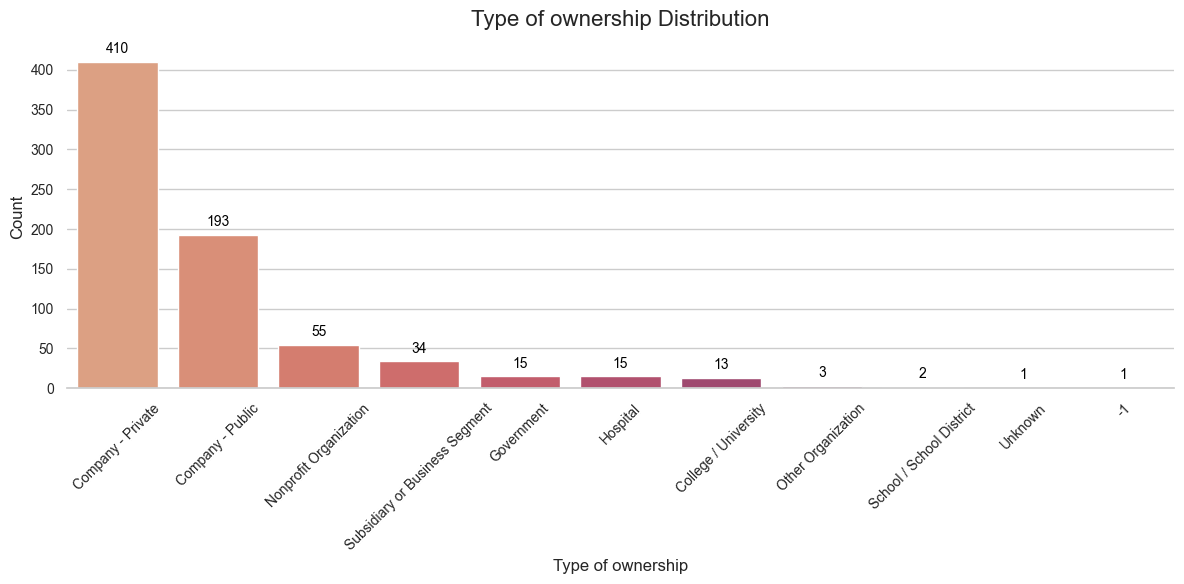

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


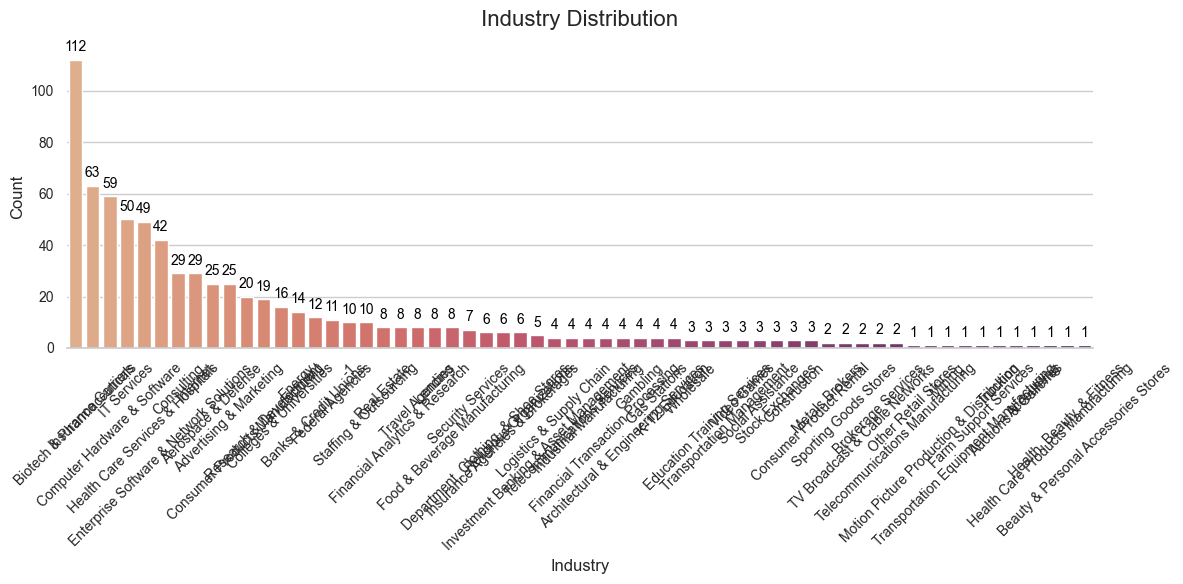

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


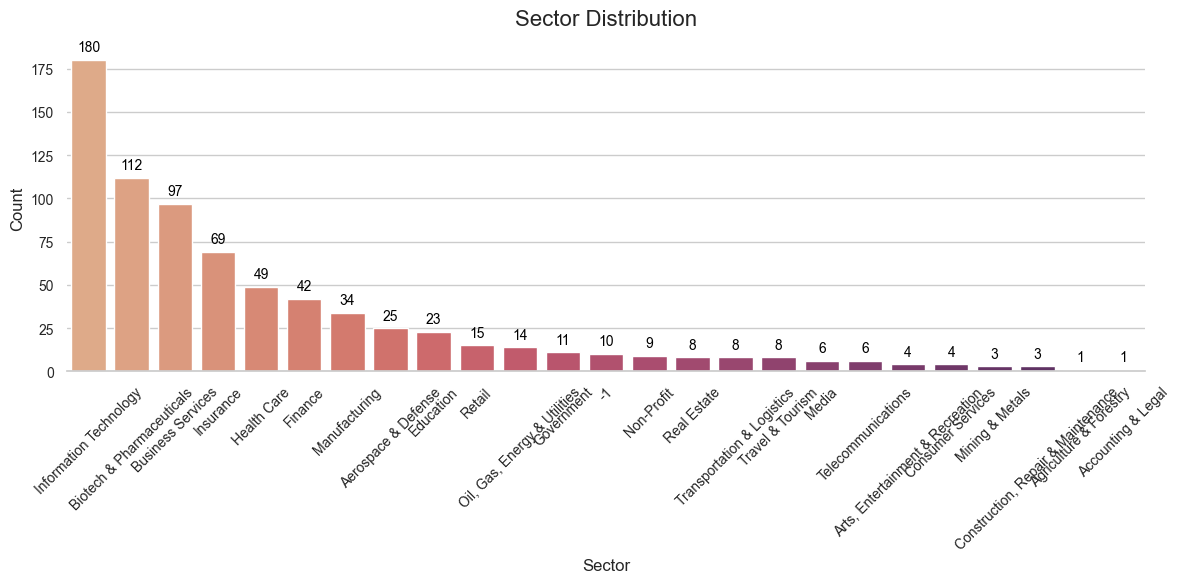

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


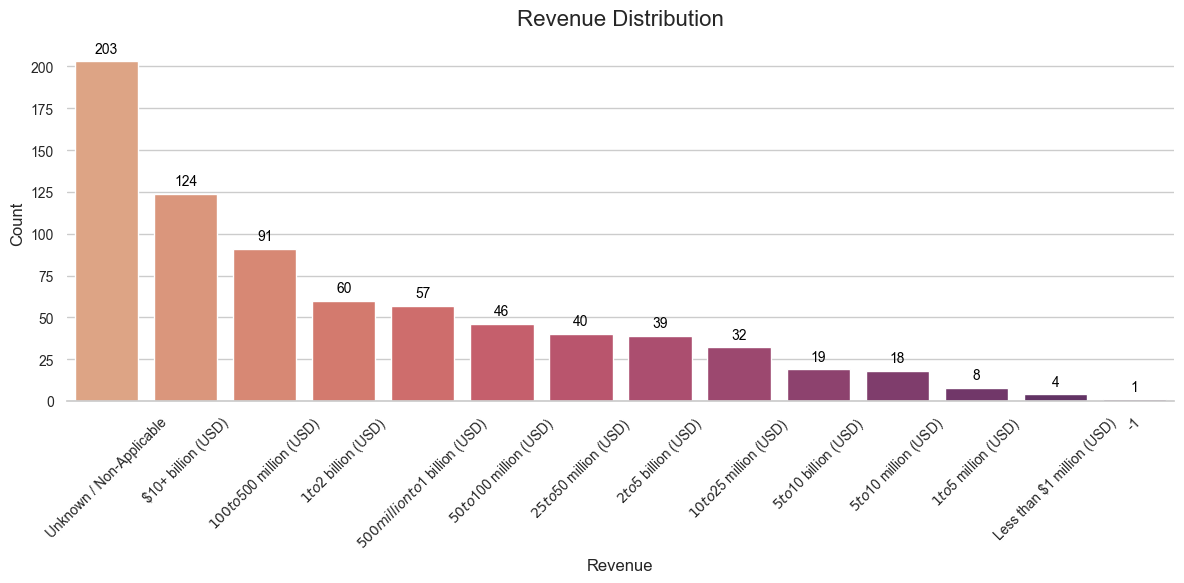

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)
) missing from font(s) Arial.\Temp\ipykernel_7708\4001754057.py:28: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) Arial.\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


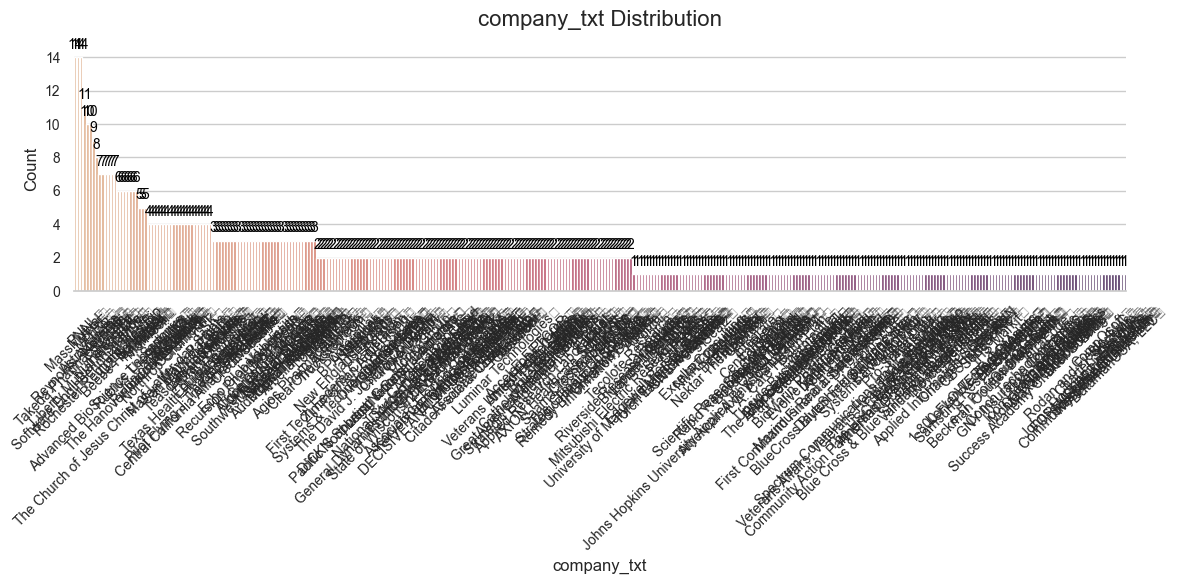

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


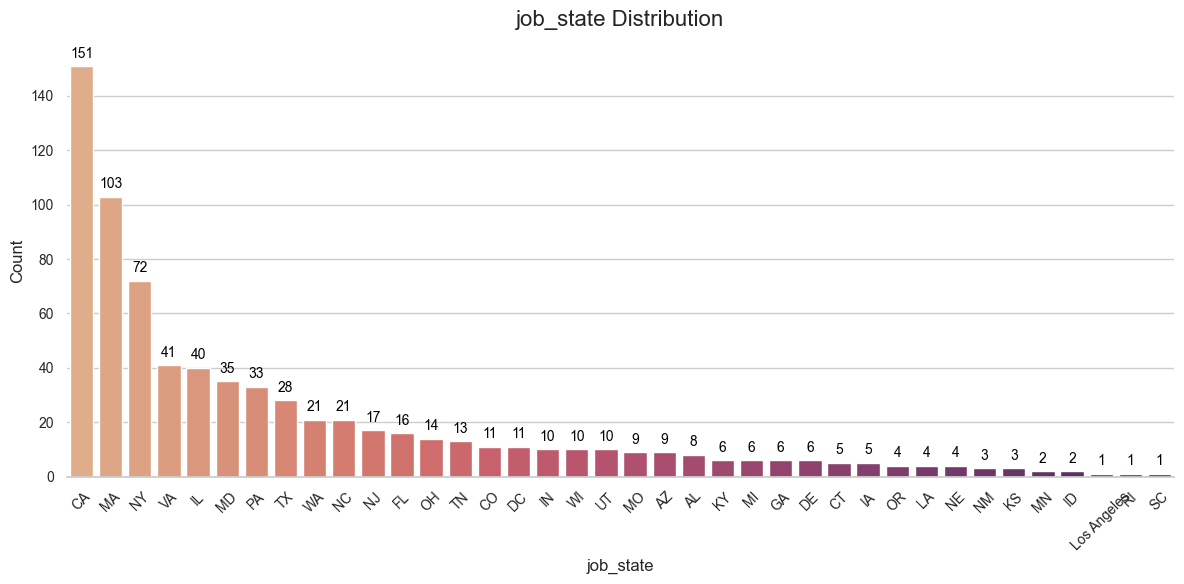

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


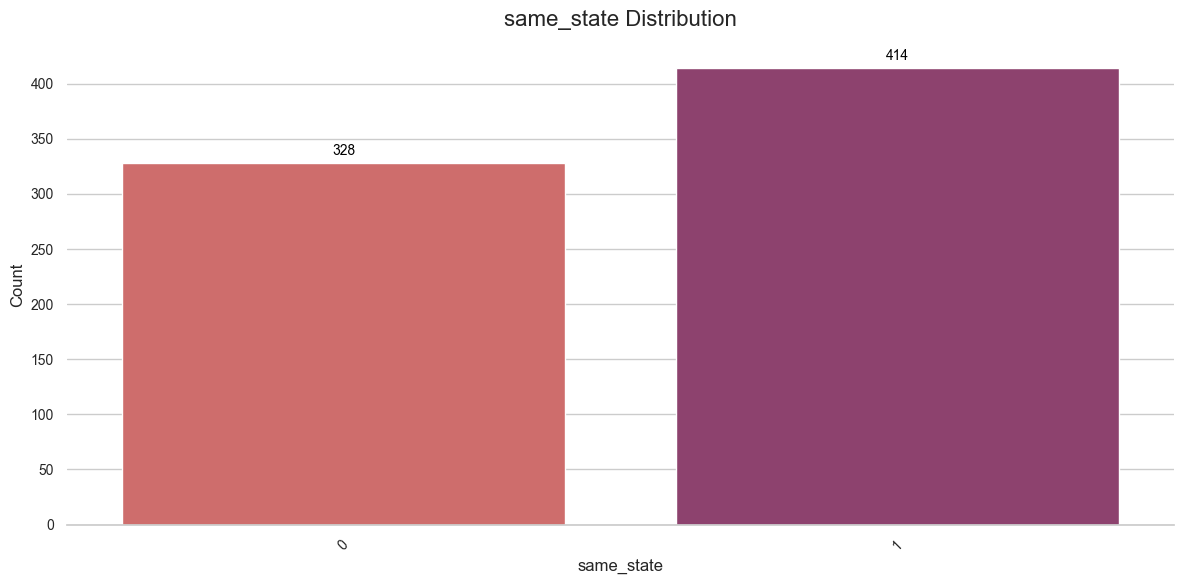

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


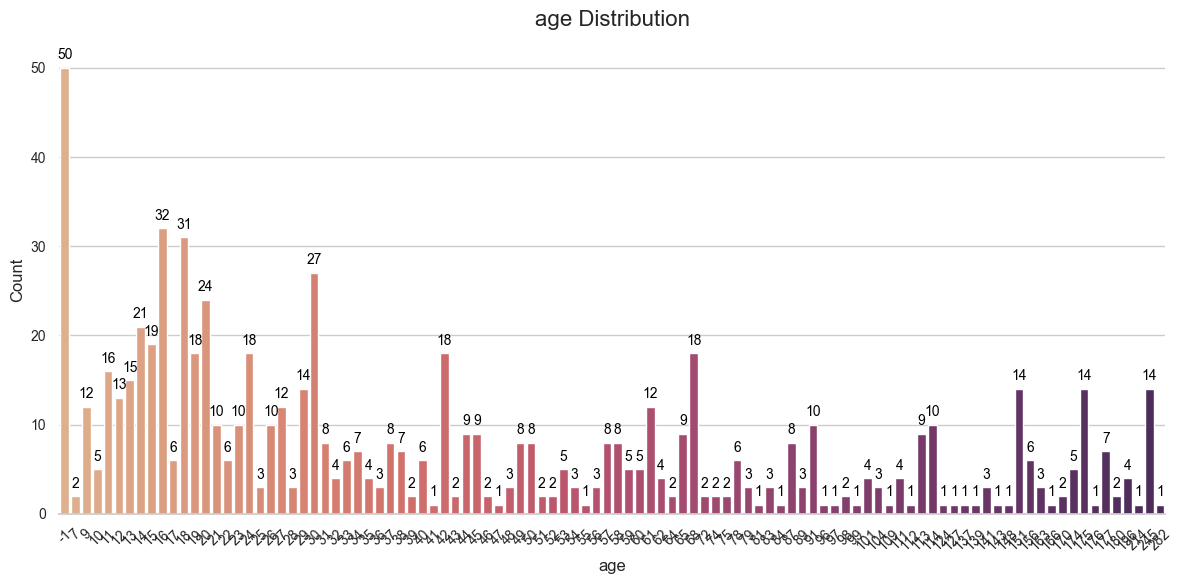

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


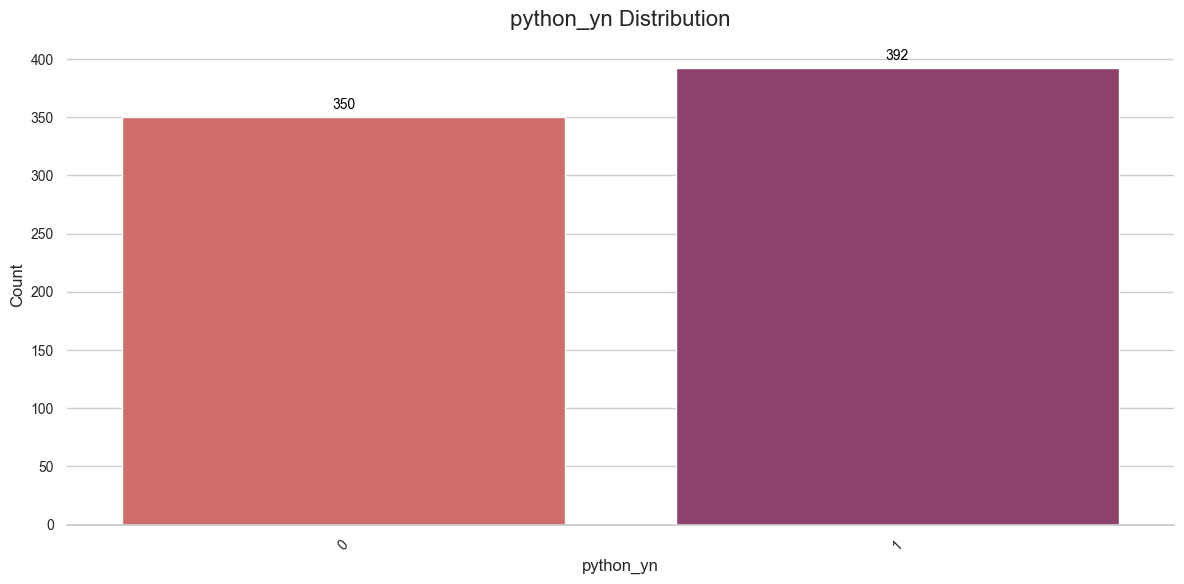

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


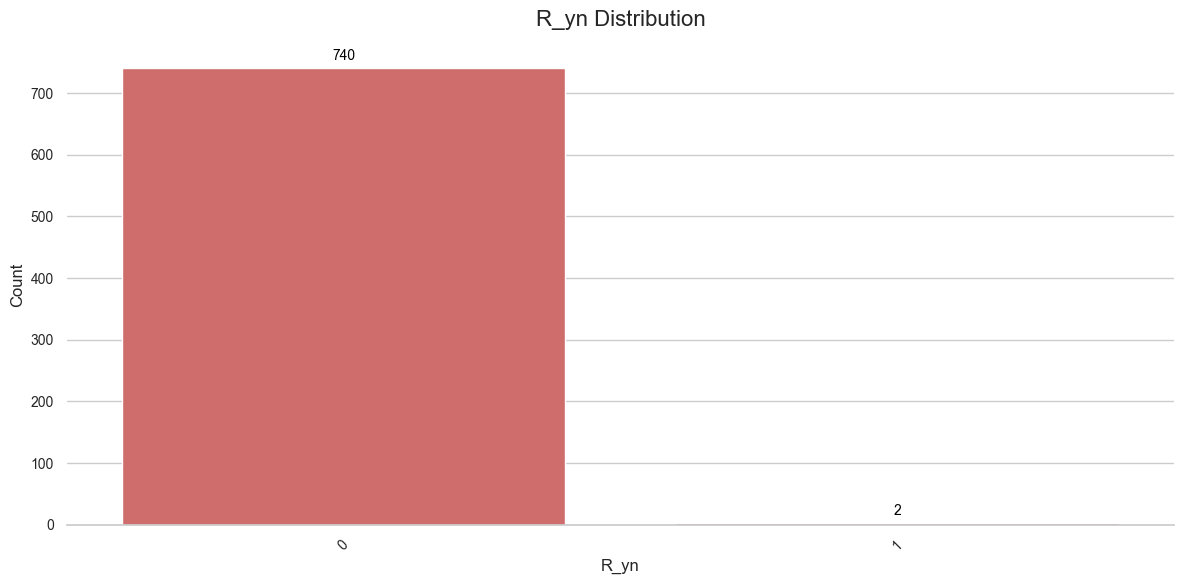

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


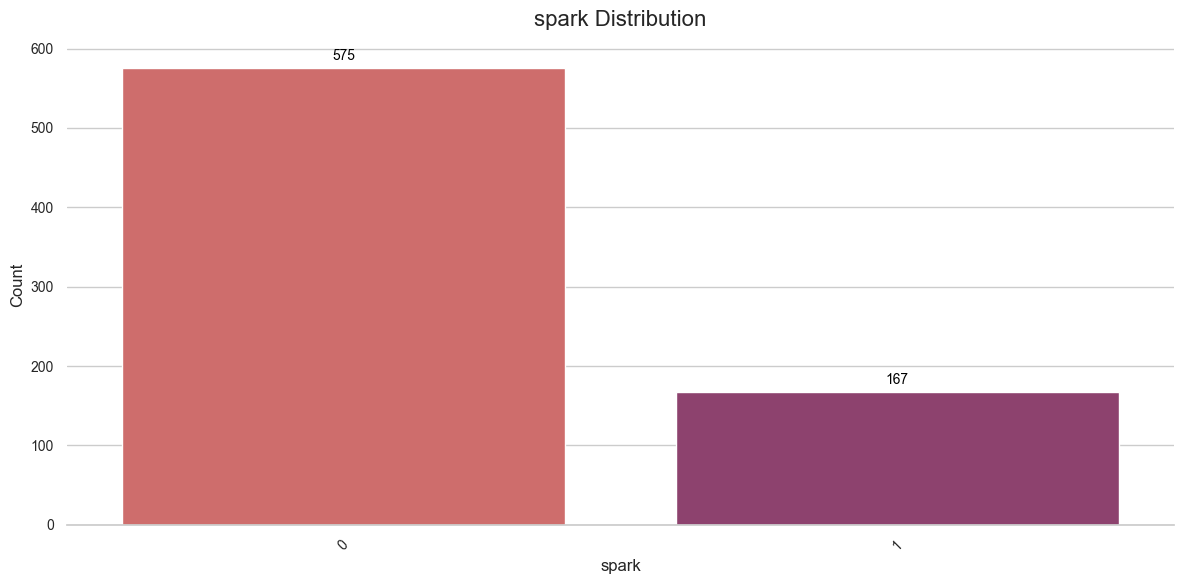

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


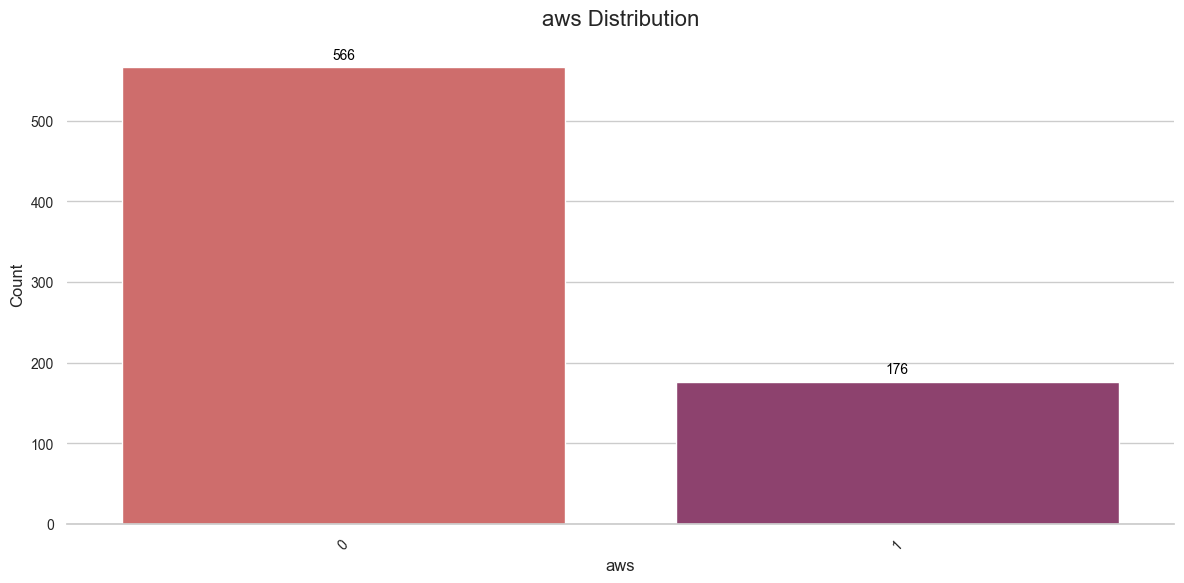

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


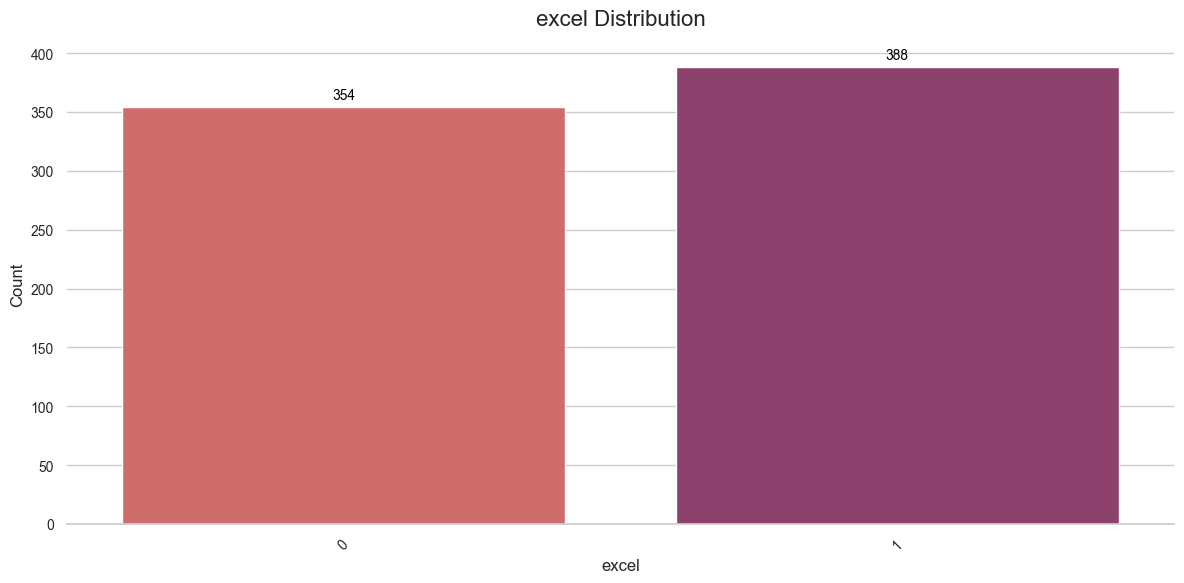

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


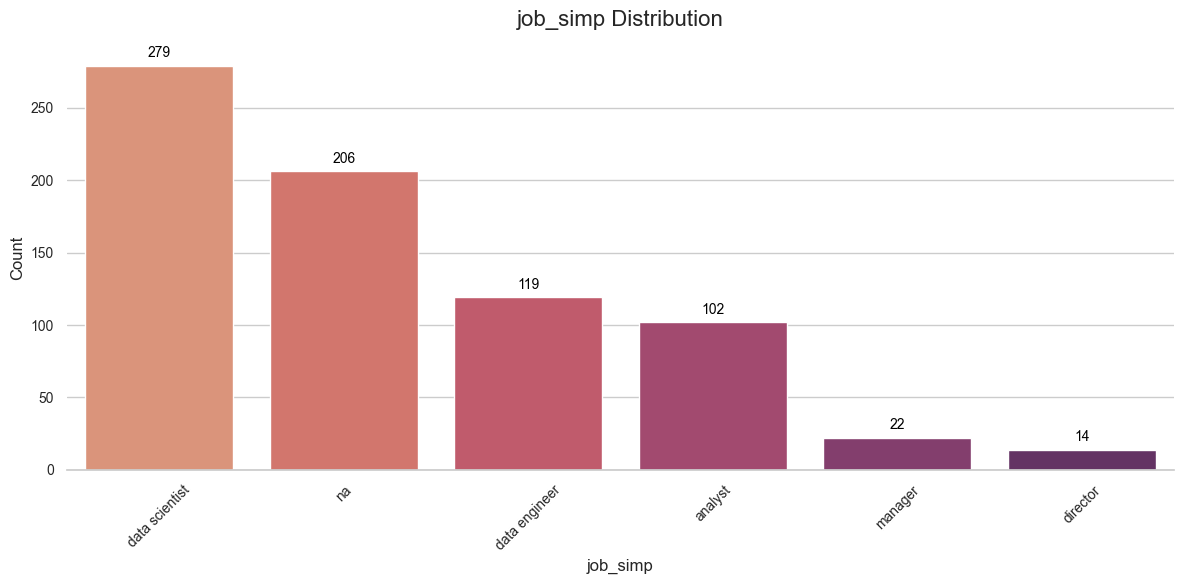

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7708\4001754057.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


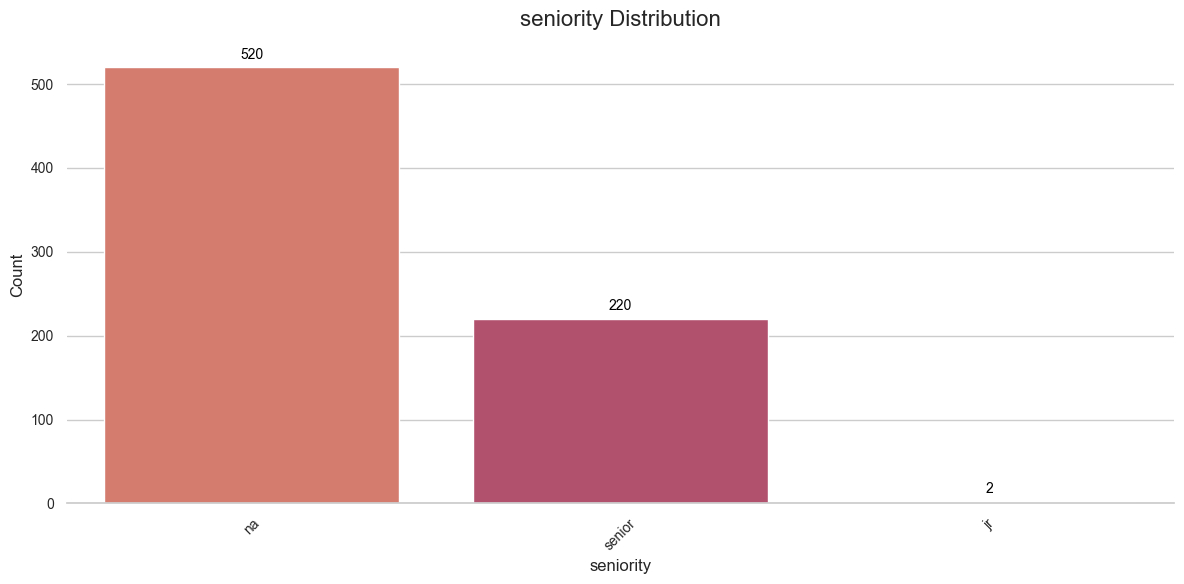

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

for i in df_cat.columns:
    counts = df_cat[i].value_counts()
    colors = sns.color_palette('flare', len(counts))

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)
    ax.set_title(f'{i} Distribution', fontsize=16, pad=14)
    ax.set_xlabel(i, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height):,}',
                        (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom',
                        fontsize=10, color='black', xytext=(0, 4),
                        textcoords='offset points')

    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.show()